# **Data Preprocessing Techniques in Machine Learning**

Data preprocessing is a crucial step in the machine learning pipeline. It involves cleaning, transforming, and wrangling raw data to prepare it for modeling.



*   ***Data cleaning*** removes incorrect, inconsistent, or irrelevant information. Techniques include handling missing values and dealing with outliers. These methods are essential for creating accurate and unbiased models
*   ***Feature Scaling*** (Data normalization and scaling) techniques transform data to a standardized range, ensuring all features contribute equally to the model. This is particularly important for algorithms sensitive to the scale of their input data, like SVM and k-Nearest Neighbors (k-NN).
*  ***Data encoding*** is another method for preparing categorical variables for modeling. Encoding techniques, such as one-hot encoding and label encoding, convert categorical variables into numerical features.



**===============================================================**

**Data Cleaning**

**1- Advanced SimpleImputer Techniques**

SimpleImputer handles missing values through various strategies including mean, median, most_frequent, and constant. This implementation demonstrates multiple imputation strategies and handling different data types simultaneously.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# Create dataset with missing values
data = np.array([
    [np.nan, 2, 3, np.nan],
    [4, np.nan, 6, 8],
    [10, 11, np.nan, 13],
    [14, 15, 16, np.nan]
])

# Different imputation strategies
strategies = ['mean', 'median', 'most_frequent', 'constant']
imputed_data = {}

for strategy in strategies:
    imputer = SimpleImputer(
        missing_values=np.nan,
        strategy=strategy,
        fill_value=999 if strategy == 'constant' else None
    )
    imputed_data[strategy] = imputer.fit_transform(data)

# Display results
for strategy, imp_data in imputed_data.items():
    print(f"\nImputed data using {strategy} strategy:")
    print(imp_data)
    print(f"Statistics for {strategy}:")
    print("Mean:", np.mean(imp_data, axis=0))
    print("Median:", np.median(imp_data, axis=0))


Imputed data using mean strategy:
[[ 9.33333333  2.          3.         10.5       ]
 [ 4.          9.33333333  6.          8.        ]
 [10.         11.          8.33333333 13.        ]
 [14.         15.         16.         10.5       ]]
Statistics for mean:
Mean: [ 9.33333333  9.33333333  8.33333333 10.5       ]
Median: [ 9.66666667 10.16666667  7.16666667 10.5       ]

Imputed data using median strategy:
[[10.   2.   3.  10.5]
 [ 4.  11.   6.   8. ]
 [10.  11.   6.  13. ]
 [14.  15.  16.  10.5]]
Statistics for median:
Mean: [ 9.5   9.75  7.75 10.5 ]
Median: [10.  11.   6.  10.5]

Imputed data using most_frequent strategy:
[[ 4.  2.  3.  8.]
 [ 4.  2.  6.  8.]
 [10. 11.  3. 13.]
 [14. 15. 16.  8.]]
Statistics for most_frequent:
Mean: [8.   7.5  7.   9.25]
Median: [7.  6.5 4.5 8. ]

Imputed data using constant strategy:
[[999.   2.   3. 999.]
 [  4. 999.   6.   8.]
 [ 10.  11. 999.  13.]
 [ 14.  15.  16. 999.]]
Statistics for constant:
Mean: [256.75 256.75 256.   504.75]
Median: [ 12

**2- KNNImputer with Distance-Based Imputation**

KNNImputer provides sophisticated missing value imputation using k-nearest neighbors algorithm. This implementation shows how to handle missing values based on feature similarity and distance metrics.

In [ ]:
import numpy as np
from sklearn.impute import KNNImputer
import pandas as pd

# Create dataset with missing values
X = np.array([
    [1.0, np.nan, 3.0, 4.0],
    [4.0, 2.0, np.nan, 1.0],
    [np.nan, 5.0, 6.0, 8.0],
    [2.0, 3.0, 4.0, np.nan],
    [7.0, 8.0, 9.0, 1.0]
])

# Initialize and apply KNNImputer with different configurations
imputers = {
    'uniform': KNNImputer(n_neighbors=2, weights='uniform'),
    'distance': KNNImputer(n_neighbors=2, weights='distance')
}

results = {}
for name, imputer in imputers.items():
    results[name] = imputer.fit_transform(X)

# Display and compare results
print("Original data with missing values:\n", X)
for name, imputed_data in results.items():
    print(f"\nImputed data using {name} weights:")
    print(imputed_data)
    print(f"Imputation statistics for {name}:")
    print("Mean:", np.mean(imputed_data, axis=0))
    print("Std:", np.std(imputed_data, axis=0))

Original data with missing values:
 [[ 1. nan  3.  4.]
 [ 4.  2. nan  1.]
 [nan  5.  6.  8.]
 [ 2.  3.  4. nan]
 [ 7.  8.  9.  1.]]

Imputed data using uniform weights:
[[1.  2.5 3.  4. ]
 [4.  2.  3.5 1. ]
 [1.5 5.  6.  8. ]
 [2.  3.  4.  2.5]
 [7.  8.  9.  1. ]]
Imputation statistics for uniform:
Mean: [3.1 4.1 5.1 3.3]
Std: [2.2 2.2 2.2 2.6]

Imputed data using distance weights:
[[1.         2.75       3.         4.        ]
 [4.         2.         3.654859   1.        ]
 [1.6386979  5.         6.         8.        ]
 [2.         3.         4.         2.83772234]
 [7.         8.         9.         1.        ]]
Imputation statistics for distance:
Mean: [3.12773958 4.15       5.1309718  3.36754447]
Std: [2.18043832 2.16564078 2.17823948 2.58266875]


**===============================================================**

**Feature Scaling**

**1- StandardScaler Implementation and Applications**

StandardScaler transforms features by removing the mean and scaling to unit variance, resulting in a distribution with a mean of 0 and standard deviation of 1. This technique is crucial when features have varying scales and for algorithms sensitive to feature magnitudes like gradient descent-based methods.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create sample dataset
data = np.array([
    [1, 200, 3],
    [2, 300, 4],
    [3, 400, 5],
    [4, 500, 6]
])

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the data
scaled_data = scaler.fit_transform(data)

# Show original vs scaled data
df = pd.DataFrame({
    "Original_F1": data[:, 0],
    "Original_F2": data[:, 1],
    "Original_F3": data[:, 2],
    "Scaled_F1": scaled_data[:, 0],
    "Scaled_F2": scaled_data[:, 1],
    "Scaled_F3": scaled_data[:, 2],
})

print("Original vs Scaled Data:")
print(df)

# Display mean and standard deviation of scaled features
print("\nMean of scaled features:", scaled_data.mean(axis=0))
print("Std of scaled features:", scaled_data.std(axis=0))

Original vs Scaled Data:
   Original_F1  Original_F2  Original_F3  Scaled_F1  Scaled_F2  Scaled_F3
0            1          200            3  -1.341641  -1.341641  -1.341641
1            2          300            4  -0.447214  -0.447214  -0.447214
2            3          400            5   0.447214   0.447214   0.447214
3            4          500            6   1.341641   1.341641   1.341641

Mean of scaled features: [0. 0. 0.]
Std of scaled features: [1. 1. 1.]


**2- MinMaxScaler Implementation**

MinMaxScaler transforms features by scaling them to a given range, typically [0,1]. This technique preserves zero entries and is optimal when the distribution is not Gaussian or when standard deviation is small.

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Generate sample data with different scales
X = np.array([[1, -1, 2],
              [2, 0, 0],
              [0, 1, -1]])

# Initialize and apply MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Display results
print("Original data:\n", X)
print("\nScaled data:\n", X_scaled)
print("\nFeature ranges:")
print("Min values:", X_scaled.min(axis=0))
print("Max values:", X_scaled.max(axis=0))

Original data:
 [[ 1 -1  2]
 [ 2  0  0]
 [ 0  1 -1]]

Scaled data:
 [[0.5        0.         1.        ]
 [1.         0.5        0.33333333]
 [0.         1.         0.        ]]

Feature ranges:
Min values: [0. 0. 0.]
Max values: [1. 1. 1.]


**3- RobustScaler for Outlier Handling**

RobustScaler uses statistics that are robust to outliers. It removes the median and scales data according to the IQR (Interquartile Range). This approach makes it particularly useful for datasets where standard scaling might be influenced by extreme values.

In [ ]:
import numpy as np
from sklearn.preprocessing import RobustScaler

# Create dataset with outliers
data = np.array([[1], [2], [3], [1000], [4], [5]])

# Apply RobustScaler
robust_scaler = RobustScaler()
data_robust = robust_scaler.fit_transform(data)

# Compare with StandardScaler
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
data_standard = standard_scaler.fit_transform(data)

print("Original data:", data.ravel())
print("RobustScaler:", data_robust.ravel())
print("StandardScaler:", data_standard.ravel())

Original data: [   1    2    3 1000    4    5]
RobustScaler: [-1.000e+00 -6.000e-01 -2.000e-01  3.986e+02  2.000e-01  6.000e-01]
StandardScaler: [-0.45259357 -0.44990224 -0.4472109   2.23605448 -0.44451956 -0.44182822]


**4- Normalizer Implementation**

Normalizer scales individual samples independently of each other to have unit norm. This preprocessing step is useful for text classification and clustering, where the relative frequencies of features are more important than absolute frequencies.

In [ ]:
import numpy as np
from sklearn.preprocessing import Normalizer

# Create sample data
X = np.array([[4, 1, 2, 2],
              [1, 3, 9, 3],
              [5, 7, 5, 1]])

# Initialize and apply Normalizer
normalizer = Normalizer(norm='l2')  # l2 norm
X_normalized = normalizer.fit_transform(X)

# Calculate and display norms
original_norms = np.linalg.norm(X, axis=1)
normalized_norms = np.linalg.norm(X_normalized, axis=1)

print("Original data:\n", X)
print("\nNormalized data:\n", X_normalized)
print("\nOriginal norms:", original_norms)
print("Normalized norms:", normalized_norms)

Original data:
 [[4 1 2 2]
 [1 3 9 3]
 [5 7 5 1]]

Normalized data:
 [[0.8 0.2 0.4 0.4]
 [0.1 0.3 0.9 0.3]
 [0.5 0.7 0.5 0.1]]

Original norms: [ 5. 10. 10.]
Normalized norms: [1. 1. 1.]


**5- Binarizer with Custom Thresholds**

Binarizer transforms numerical features into binary values based on a threshold. This transformation is particularly useful in feature engineering when you need to convert continuous variables into binary flags or when implementing decision boundaries.

In [ ]:
import numpy as np
from sklearn.preprocessing import Binarizer

# Create sample continuous data
X = np.array([[0.1, 2.5, 3.8],
              [1.5, -0.2, 4.2],
              [3.2, 1.8, -0.5]])

# Initialize and apply Binarizer with different thresholds
binarizer_default = Binarizer(threshold=2.0)
X_binary = binarizer_default.fit_transform(X)

print("Original data:\n", X)
print("\nBinarized data (threshold=2.0):\n", X_binary)

# Example with multiple thresholds
thresholds = [1.0, 2.0, 3.0]
for threshold in thresholds:
    binarizer = Binarizer(threshold=threshold)
    print(f"\nBinarized data (threshold={threshold}):\n",
          binarizer.fit_transform(X))

Original data:
 [[ 0.1  2.5  3.8]
 [ 1.5 -0.2  4.2]
 [ 3.2  1.8 -0.5]]

Binarized data (threshold=2.0):
 [[0. 1. 1.]
 [0. 0. 1.]
 [1. 0. 0.]]

Binarized data (threshold=1.0):
 [[0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 0.]]

Binarized data (threshold=2.0):
 [[0. 1. 1.]
 [0. 0. 1.]
 [1. 0. 0.]]

Binarized data (threshold=3.0):
 [[0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]]


**6- MaxAbsScaler with Sparse Data**

MaxAbsScaler scales each feature by its maximum absolute value, making it particularly useful for sparse data and maintaining zero values. This implementation demonstrates its application on both dense and sparse matrices.

In [ ]:
import numpy as np
from sklearn.preprocessing import MaxAbsScaler
from scipy.sparse import csr_matrix

# Create sample dense and sparse data
X_dense = np.array([[ 1., -1.,  2.],
                   [ 2.,  0.,  0.],
                   [ 0.,  1., -1.]])

X_sparse = csr_matrix([[ 1.,  0.,  2.],
                      [ 2.,  0.,  0.],
                      [ 0.,  1.,  0.]])

# Initialize and fit scaler
scaler = MaxAbsScaler()

# Transform both dense and sparse data
X_dense_scaled = scaler.fit_transform(X_dense)
X_sparse_scaled = scaler.fit_transform(X_sparse)

# Display results
print("Dense Data:")
print("Original:\n", X_dense)
print("\nScaled:\n", X_dense_scaled)
print("\nScaling factors:", scaler.scale_)

print("\nSparse Data:")
print("Original:\n", X_sparse.toarray())
print("\nScaled:\n", X_sparse_scaled.toarray())

# Verify zero preservation
print("\nZero Preservation Check:")
print("Dense zeros maintained:",
      np.array_equal((X_dense == 0), (X_dense_scaled == 0)))
print("Sparse zeros maintained:",
      np.array_equal((X_sparse.toarray() == 0), (X_sparse_scaled.toarray() == 0)))

**===============================================================**

**Data encoding**

**1- LabelEncoder Advanced Usage**

LabelEncoder transforms categorical labels into numerical values, enabling categorical data processing in machine learning algorithms. This implementation demonstrates handling multiple categories and dealing with unknown labels.

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Sample categorical data
categories = np.array(['cat', 'dog', 'bird', 'cat', 'fish', 'dog', 'bird'])

# Initialize and fit LabelEncoder
label_encoder = LabelEncoder()
encoded_data = label_encoder.fit_transform(categories)

# Create mapping dictionary
label_mapping = dict(zip(label_encoder.classes_,
                        label_encoder.transform(label_encoder.classes_)))

print("Original categories:", categories)
print("Encoded categories:", encoded_data)
print("\nLabel mapping:", label_mapping)

# Handle new/unknown categories
try:
    new_categories = np.array(['cat', 'dog', 'elephant'])
    print("\nTrying to transform new category:")
    print(label_encoder.transform(new_categories))
except ValueError as e:
    print("\nError handling unknown category:", str(e))

Original categories: ['cat' 'dog' 'bird' 'cat' 'fish' 'dog' 'bird']
Encoded categories: [1 2 0 1 3 2 0]

Label mapping: {np.str_('bird'): np.int64(0), np.str_('cat'): np.int64(1), np.str_('dog'): np.int64(2), np.str_('fish'): np.int64(3)}

Trying to transform new category:

Error handling unknown category: y contains previously unseen labels: np.str_('elep')


**2- OneHotEncoder with Sparse Matrix**

OneHotEncoder converts categorical features into a binary matrix format, creating new binary columns for each unique category. This implementation shows handling sparse matrices and dealing with unknown categories in production.

In [ ]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp

# Sample categorical data
X = np.array([['Red', 'Small'],
              ['Blue', 'Medium'],
              ['Green', 'Large'],
              ['Red', 'Medium']])

# Initialize OneHotEncoder with sparse matrix
encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X)

print("Original shape:", X.shape)
print("Encoded shape:", X_encoded.shape)
print("\nFeature names:", encoder.get_feature_names_out())
print("\nSparse matrix:\n", X_encoded.toarray())

# Handle unknown categories
new_data = np.array([['Yellow', 'Extra Large']])
print("\nEncoding unknown category:")
print(encoder.transform(new_data).toarray())

Original shape: (4, 2)
Encoded shape: (4, 6)

Feature names: ['x0_Blue' 'x0_Green' 'x0_Red' 'x1_Large' 'x1_Medium' 'x1_Small']

Sparse matrix:
 [[0. 0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0.]
 [0. 1. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0.]]

Encoding unknown category:
[[0. 0. 0. 0. 0. 0.]]


**3- Ordinal Encoding**

In [ ]:
#### Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

# Sample data representing customer education levels
data = np.array([['High School'], ['Bachelor\'s'], ['Master\'s'], ['Bachelor\'s'], ['PhD']])

# Define the explicit order for the encoder
# This ensures that 'Bachelor\'s' is correctly ranked below 'Master\'s'
education_order = [
    ['High School', 'Bachelor\'s', 'Master\'s', 'PhD']
]

# Initialize the encoder and pass the defined order
encoder = OrdinalEncoder(categories=education_order)

# Fit and transform the data
encoded_data = encoder.fit_transform(data)

print("Original Data:\n", data.flatten())
print("\nEncoded Data:\n", encoded_data.flatten())

Original Data:
 ['High School' "Bachelor's" "Master's" "Bachelor's" 'PhD']

Encoded Data:
 [0. 1. 2. 1. 3.]


**===============================================================**

**Handling Outliers**

Original data with outliers (first 10 values and last 5 outliers):
       Value
0  54.967142
1  48.617357
2  56.476885
3  65.230299
4  47.658466
5  47.658630
6  65.792128
7  57.674347
8  45.305256
9  55.425600
     Value
100    1.0
101    2.0
102   90.0
103   95.0
104  100.0


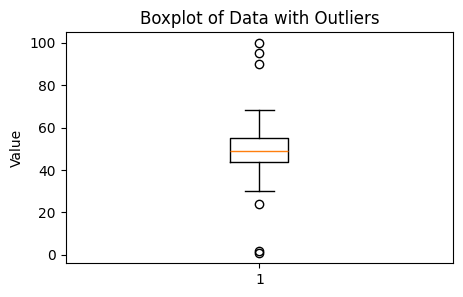


Number of original data points: 105
Q1: 43.98, Q3: 55.13, IQR: 11.15
Lower Bound: 27.26, Upper Bound: 71.86
Number of data points after outlier removal: 99

Data after outlier removal (first 10 values and last 5 values):
       Value
0  54.967142
1  48.617357
2  56.476885
3  65.230299
4  47.658466
5  47.658630
6  65.792128
7  57.674347
8  45.305256
9  55.425600
        Value
95  35.364851
96  52.961203
97  52.610553
98  50.051135
99  47.654129


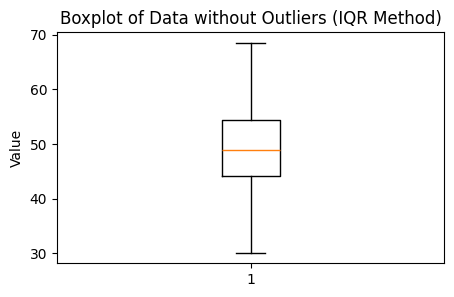

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate data with outliers
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100) # Normally distributed data
outliers = np.array([1, 2, 90, 95, 100]) # Introducing extreme outliers
data_with_outliers = np.concatenate((data, outliers))

df = pd.DataFrame(data_with_outliers, columns=['Value'])

print("Original data with outliers (first 10 values and last 5 outliers):")
print(df.head(10))
print(df.tail(5))

# Visualize original data
plt.figure(figsize=(5, 3))
plt.boxplot(df['Value'])
plt.title('Boxplot of Data with Outliers')
plt.ylabel('Value')
plt.show()

# 2. Outlier detection and removal using IQR method
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
data_no_outliers = df[(df['Value'] >= lower_bound) & (df['Value'] <= upper_bound)]

print(f"\nNumber of original data points: {len(df)}")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
print(f"Number of data points after outlier removal: {len(data_no_outliers)}")

print("\nData after outlier removal (first 10 values and last 5 values):")
print(data_no_outliers.head(10))
print(data_no_outliers.tail(5))

# Visualize data after outlier removal
plt.figure(figsize=(5, 3))
plt.boxplot(data_no_outliers['Value'])
plt.title('Boxplot of Data without Outliers (IQR Method)')
plt.ylabel('Value')
plt.show()


**===============================================================**

# Data Preprocessing Techniques Applied on the Pima Indians Diabetes Dataset.

This demonstrates data preprocessing techniques including:

---


- Missing values
- Outliers
- Feature transformation
- Encoding

In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [ ]:
# Load dataset

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
           "BMI","DiabetesPedigreeFunction","Age","Outcome"]
df = pd.read_csv(url, names=columns)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# display the total number of rows (observations) and columns (features)
print('Diabetes dataset dimensions : {}'.format(df.shape))

Diabetes dataset dimensions : (768, 9)


In [ ]:
# display all information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# check the datatype of each feature
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
# check the number of patients that have diabetic or not (1 has and 0 not)
df.groupby('Outcome').size()
# We can identify that out of the 768 persons, 500 are labeled as 0 (non-diabetic) and 268 as 1 (diabetic)

,0
Outcome,
0,500
1,268


<Axes: xlabel='Outcome', ylabel='count'>

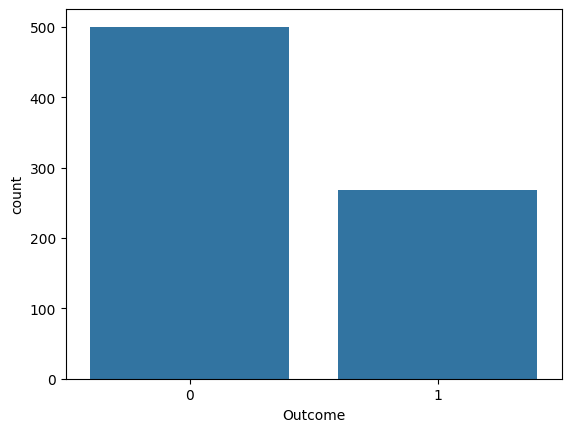

In [ ]:
# if we need to plot it
sns.countplot(x=df['Outcome'],data=df)

In [ ]:
# the number of unique observations in each feature
df.nunique()

,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


**Handling Missing Values**

🚨 Important note: Never replace zeros in columns where zero is a valid value

Example:

Pregnancies = 0 → VALID

Age = 0 → INVALID (but doesn’t exist here)

That’s why we only apply this to selected columns, not the whole dataset.

*   *Missing value calculation*: identify null values in the data.**data.isnull().sum()** or **data.isna().sum()** is used to get the number of missing records in each column and **(data.isnull().sum()/(len(data)))** is used to calculate the percentage of missing values in each column.

In [ ]:
# the total number of missing values in each column
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# the percentage of missing values in column bloodpressure is 1.17%
(df.isnull().sum()/(len(df)))*100     # the percentage of missing values in column bloodpressure is 1.17%

,0
Pregnancies,0.0
Glucose,0.0
BloodPressure,0.0
SkinThickness,0.0
Insulin,0.0
BMI,0.0
DiabetesPedigreeFunction,0.0
Age,0.0
Outcome,0.0


In [ ]:
# Replaces every 0 in those columns With np.nan, which is Python’s standard symbol
# for missing values
features_with_zero = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
df[features_with_zero] = df[features_with_zero].replace(0, np.nan)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
### Again check for null values and get the percentage
print("No. of null values in each feature")
print(df.isnull().sum())
print("Percentage of null values")
print((df.isnull().sum()/(len(df)))*100)

No. of null values in each feature
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Percentage of null values
Pregnancies                  0.000000
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64


In [ ]:
# Replace the NAN with mean values using fillna() command
df['BloodPressure']=df['BloodPressure'].fillna(df['BloodPressure'].mean())
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,0
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# Replace all features with NAN values
imputer = SimpleImputer(strategy="mean")
df[features_with_zero] = imputer.fit_transform(df[features_with_zero])
df.head()

### Same as knn
#imputer_knn = KNNImputer(n_neighbors=5)
#df[features_with_zero] = imputer_knn.fit_transform(df[features_with_zero])
#print("Missing values after KNN imputation:")
#print(df[features_with_zero].isnull().sum())
#df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


**Outlier Detection and Treatment**

Number of outliers detected per feature (before treatment):

Glucose: 0
BloodPressure: 14
SkinThickness: 87
Insulin: 164
BMI: 8


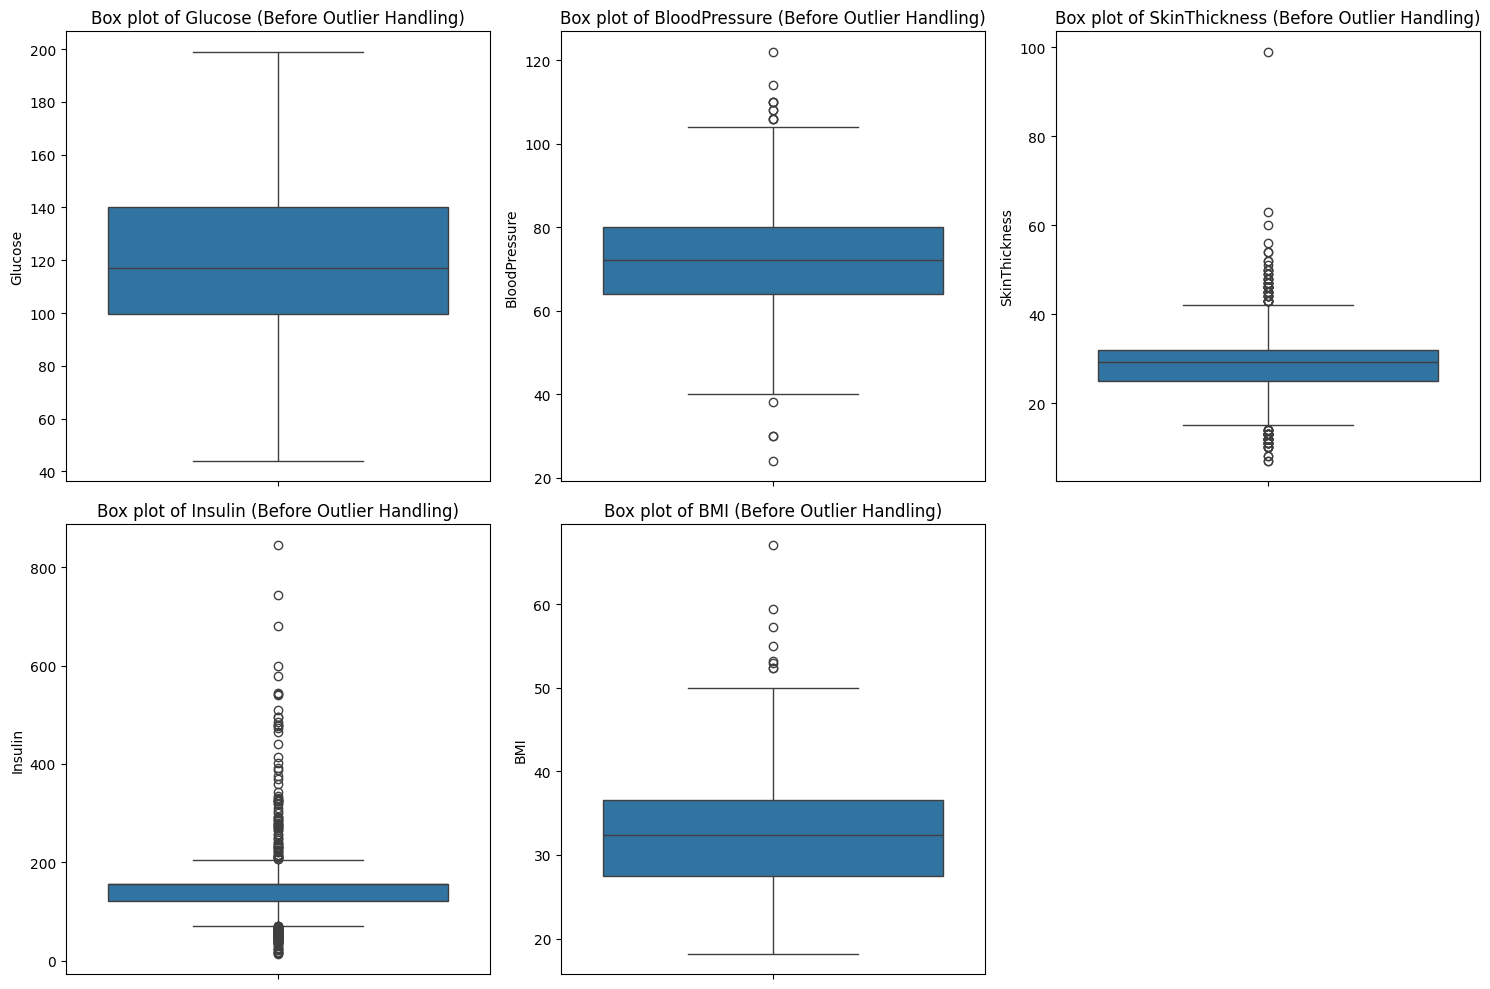

In [ ]:
# Outlier Detection using IQR method
# First, let's re-calculate Q1, Q3, and IQR based on the df_before_outlier
# to ensure we use the data state before any clipping.
Q1_before = df.quantile(0.25)
Q3_before = df.quantile(0.75)
IQR_before = Q3_before - Q1_before

print("Number of outliers detected per feature (before treatment):\n")
for column in features_with_zero:
    lower_bound = Q1_before[column] - 1.5 * IQR_before[column]
    upper_bound = Q3_before[column] + 1.5 * IQR_before[column]

    outliers_count = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]
    print(f"{column}: {outliers_count}")

# Visualize outliers using box plots (before handling)
plt.figure(figsize=(15, 10))
for i, column in enumerate(features_with_zero):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[column])
    plt.title(f'Box plot of {column} (Before Outlier Handling)')
plt.tight_layout()
plt.show()

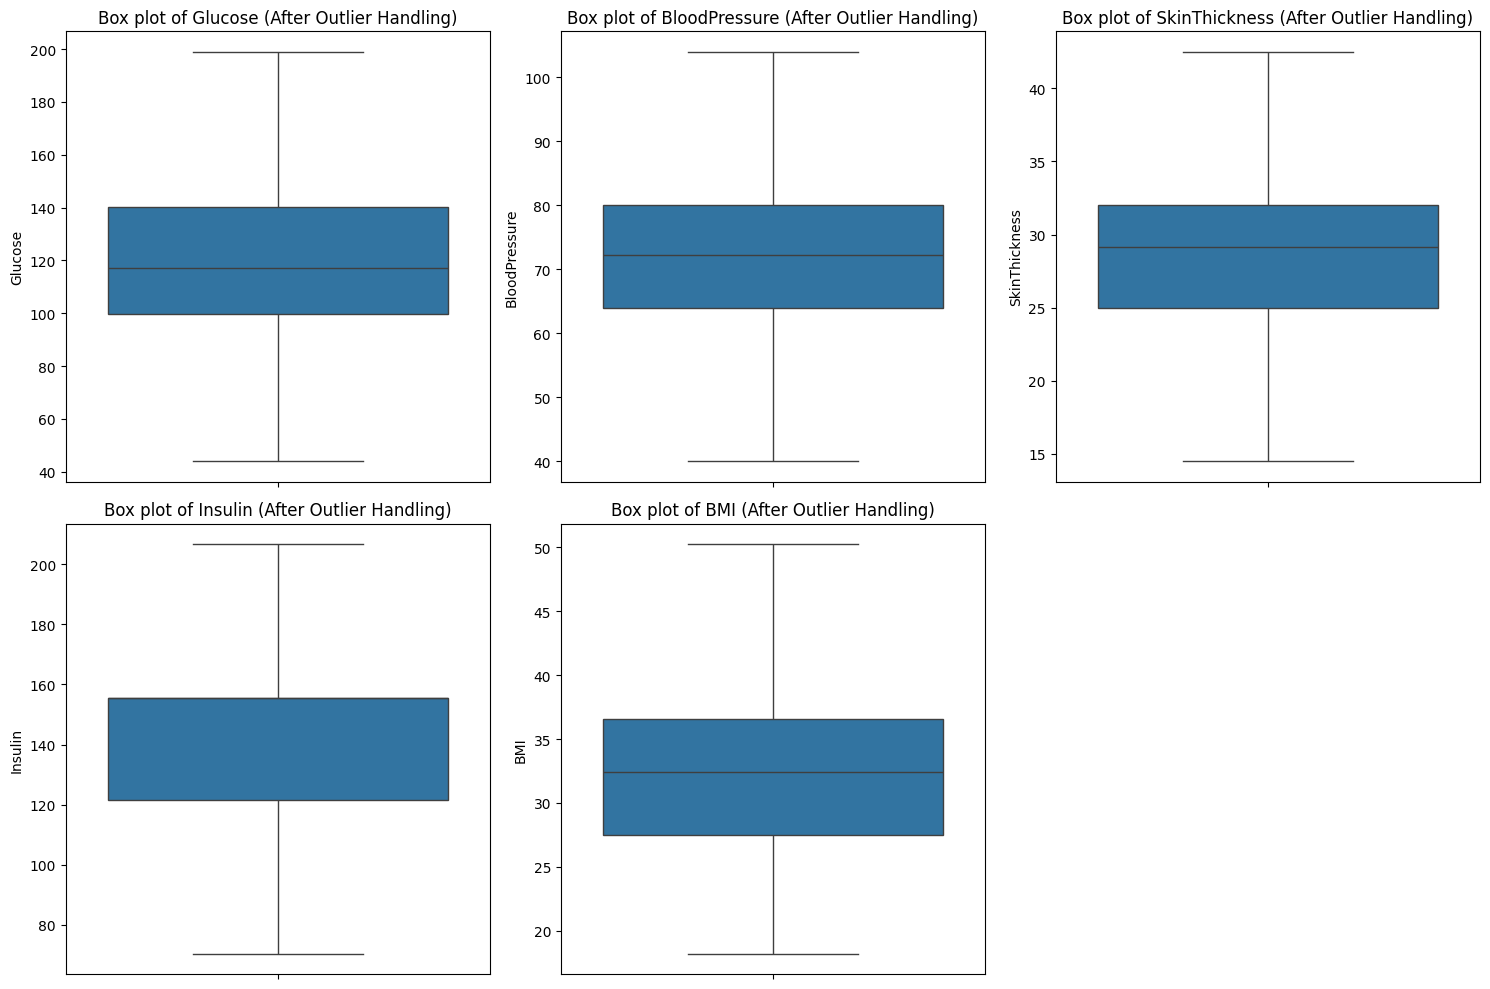

In [ ]:
### Handling outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

for col in df.columns:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df[col] = np.clip(df[col], lower, upper)

plt.figure(figsize=(15, 10))
for i, column in enumerate(features_with_zero):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[column])
    plt.title(f'Box plot of {column} (After Outlier Handling)')
plt.tight_layout()
plt.show()

**Feature engineering:** it refers to the process of using domain knowledge to select and transform the most relevant variables from raw data when creating a predictive model using machine learning or statistical modeling. The main goal of Feature engineering is to create meaningful data from raw data.

*   *Feature creation:* We will play around with the variable Age and create another feature represents the year of birth 'Birth_Year'

In [ ]:
from datetime import date
date.today().year
df['Birth_Year']=date.today().year-df['Age']
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Birth_Year
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1,1975.0
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0,1994.0
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1,1993.0
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0,2004.0
4,0.0,137.0,40.0,35.00000,168.000000,43.1,1.200,33.0,1,1992.0


*   *Feature extraction:* Also, extract from the Age a new feature based on it

In [ ]:
# feature extraction
df.loc[(df["Age"] >= 21) & (df["Age"] < 50), "NEW_AGE_CAT"] = "mature"
df.loc[(df["Age"] >= 50), "NEW_AGE_CAT"] = "senior"
df.head()

,Pregnancies,Glucose,Bloodpressure,Skinthickness,Insulin,Bmi,Diabetespedigreefunction,Age,Outcome,Birth_year,New_age_cat_encoded,NEW_AGE_CAT
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1,1975.0,1,senior
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0,1994.0,0,mature
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1,1993.0,0,mature
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0,2004.0,0,mature
4,0.0,137.0,40.0,35.00000,168.000000,43.1,1.200,33.0,1,1992.0,0,mature


*   *Working with columns*: change all to upper case letter

In [ ]:
df.columns = [col.upper() for col in df.columns]
df.head()
df.columns = [col.lower() for col in df.columns]
df.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome,birth_year,new_age_cat_encoded,new_age_cat
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1,1975.0,1,senior
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0,1994.0,0,mature
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1,1993.0,0,mature
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0,2004.0,0,mature
4,0.0,137.0,40.0,35.00000,168.000000,43.1,1.200,33.0,1,1992.0,0,mature


In [ ]:
df.columns=df.columns.str.capitalize()
df.columns

Index(['Pregnancies', 'Glucose', 'Bloodpressure', 'Skinthickness', 'Insulin',
       'Bmi', 'Diabetespedigreefunction', 'Age', 'Outcome', 'Birth_year',
       'New_age_cat_encoded', 'New_age_cat'],
      dtype='object')

*   *Split the dataset*: We separate the data set into features and the response that we are going to predict. We will assign the features to the **X** variable and the response to the **y** variable.


In [ ]:
feature_names = ['Pregnancies', 'Glucose', 'Bloodpressure', 'Skinthickness', 'Insulin',
       'Bmi', 'Diabetespedigreefunction', 'Age', 'Birth_year',
       'New_age_cat']
X = df[feature_names]
y = df.Outcome
X.head()

,Pregnancies,Glucose,Bloodpressure,Skinthickness,Insulin,Bmi,Diabetespedigreefunction,Age,Birth_year,New_age_cat
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1975.0,senior
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,1994.0,mature
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1993.0,mature
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,2004.0,mature
4,0.0,137.0,40.0,35.00000,168.000000,43.1,1.200,33.0,1992.0,mature


**Exploratory Data Analysis (EDA):** it refers to the crucial process of performing initial investigations on data to discover patterns to check assumptions with the help of summary statistics and graphical representations.

*   Statistical summary: get information about the mean, std and more for each feature.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.837240,3.344157,0.000000,1.00000,3.000000,6.000000,13.500000
Glucose,768.0,121.686763,30.435949,44.000000,99.75000,117.000000,140.250000,199.000000
Bloodpressure,768.0,72.376538,11.696836,40.000000,64.00000,72.202592,80.000000,104.000000
Skinthickness,768.0,28.911883,7.443497,14.500000,25.00000,29.153420,32.000000,42.500000
Insulin,768.0,143.937487,39.496793,70.427665,121.50000,155.548223,155.548223,206.620558
Bmi,768.0,32.395615,6.667466,18.200000,27.50000,32.400000,36.600000,50.250000
Diabetespedigreefunction,768.0,0.458914,0.285596,0.078000,0.24375,0.372500,0.626250,1.200000
Age,768.0,33.199870,11.628404,21.000000,24.00000,29.000000,41.000000,66.500000
Outcome,768.0,0.348958,0.476951,0.000000,0.00000,0.000000,1.000000,1.000000
Birth_year,768.0,1991.800130,11.628404,1958.500000,1984.00000,1996.000000,2001.000000,2004.000000


In [ ]:
# check the Quartiles
df.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T

,count,mean,std,min,0%,5%,50%,95%,99%,100%,max
Pregnancies,768.0,3.837240,3.344157,0.000000,0.000000,0.000000,3.000000,10.000000,13.000000,13.500000,13.500000
Glucose,768.0,121.686763,30.435949,44.000000,44.000000,80.000000,117.000000,181.000000,196.000000,199.000000,199.000000
Bloodpressure,768.0,72.376538,11.696836,40.000000,40.000000,52.000000,72.202592,90.000000,104.000000,104.000000,104.000000
Skinthickness,768.0,28.911883,7.443497,14.500000,14.500000,14.675000,29.153420,42.500000,42.500000,42.500000,42.500000
Insulin,768.0,143.937487,39.496793,70.427665,70.427665,70.427665,155.548223,206.620558,206.620558,206.620558,206.620558
Bmi,768.0,32.395615,6.667466,18.200000,18.200000,22.235000,32.400000,44.395000,50.082500,50.250000,50.250000
Diabetespedigreefunction,768.0,0.458914,0.285596,0.078000,0.078000,0.140350,0.372500,1.132850,1.200000,1.200000,1.200000
Age,768.0,33.199870,11.628404,21.000000,21.000000,21.000000,29.000000,58.000000,66.500000,66.500000,66.500000
Outcome,768.0,0.348958,0.476951,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
Birth_year,768.0,1991.800130,11.628404,1958.500000,1958.500000,1967.000000,1996.000000,2004.000000,2004.000000,2004.000000,2004.000000


In [ ]:
# -- if we need to separate the categorial varibles and numeical
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['New_age_cat'], dtype='object')
Numerical Variables:
['Pregnancies', 'Glucose', 'Bloodpressure', 'Skinthickness', 'Insulin', 'Bmi', 'Diabetespedigreefunction', 'Age', 'Outcome', 'Birth_year', 'New_age_cat_encoded']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the 'New_age_cat' column
df['New_age_cat_encoded'] = le.fit_transform(df['New_age_cat'])

print("Original 'New_age_cat' column:")
print(df[['New_age_cat', 'New_age_cat_encoded']].head())

print("\nEncoded 'New_age_cat' column unique values and their mapping:")
for i, item in enumerate(le.classes_):
    print(f"{item} : {i}")

df.head()

Original 'New_age_cat' column:
  New_age_cat  New_age_cat_encoded
0      senior                    1
1      mature                    0
2      mature                    0
3      mature                    0
4      mature                    0

Encoded 'New_age_cat' column unique values and their mapping:
mature : 0
senior : 1


,Pregnancies,Glucose,Bloodpressure,Skinthickness,Insulin,Bmi,Diabetespedigreefunction,Age,Outcome,Birth_year,New_age_cat_encoded,New_age_cat
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1,1975.0,1,senior
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0,1994.0,0,mature
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1,1993.0,0,mature
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0,2004.0,0,mature
4,0.0,137.0,40.0,35.00000,168.000000,43.1,1.200,33.0,1,1992.0,0,mature


In [ ]:
### drop the categ.
df=df.drop('New_age_cat', axis=1)
df.head()

,Pregnancies,Glucose,Bloodpressure,Skinthickness,Insulin,Bmi,Diabetespedigreefunction,Age,Outcome,Birth_year,New_age_cat_encoded
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1,1975.0,1
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0,1994.0,0
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1,1993.0,0
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0,2004.0,0
4,0.0,137.0,40.0,35.00000,168.000000,43.1,1.200,33.0,1,1992.0,0


**Data visulaization:** we must decide what charts to plot to better understand the data. we can visualize our data using Matplotlib and Seaborn libraries.
*   Matplotlib is a Python 2D plotting library used to draw basic charts we use Matplotlib.
*   Seaborn is also a python library built on top of Matplotlib that uses short lines of code to create and style statistical plots from Pandas and Numpy.

**Categorical variables** can be visualized using a Count plot, Bar Chart, Pie Plot, etc. while **Numerical Variables** can be visualized using Histogram, Box Plot, Density Plot, etc.

<Axes: >

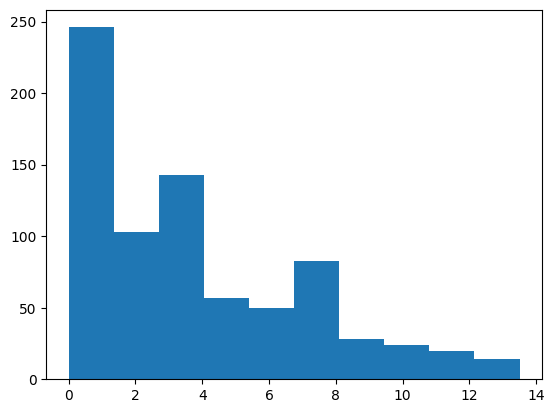

In [ ]:
df['Pregnancies'].hist(grid=False)

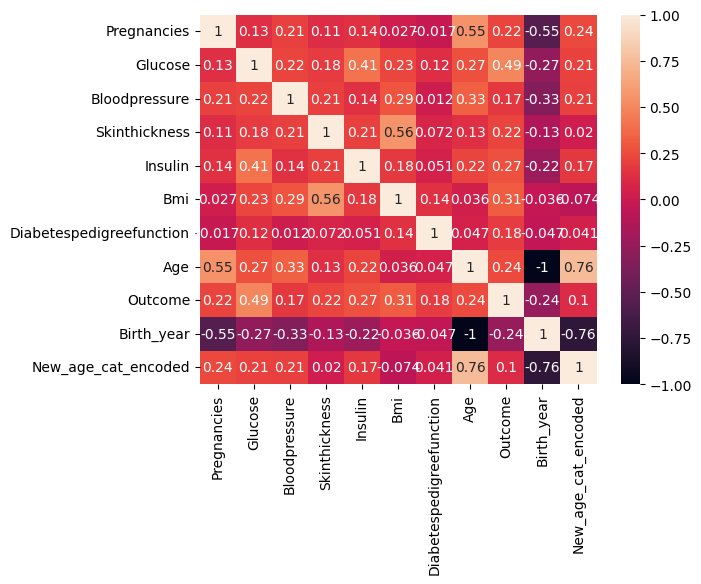

In [ ]:
# correclation between variables. In heatmap, brighter colors indicate more correlation
sns.heatmap(df.corr(), annot = True)
plt.show()

-------------------------------------------
Good Luck :) You can practice more